In [1]:
# !pip install networkx

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import koreanize_matplotlib

In [3]:
import matplotlib.font_manager as fm
import platform

# 한글 폰트 설정
if platform.system() == 'Windows':
    font_path = 'C:/Windows/Fonts/malgun.ttf'  # 맑은 고딕 경로
elif platform.system() == 'Darwin':
    font_path = '/System/Library/Fonts/AppleGothic.ttf'
else:
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# 폰트 객체 생성
font_prop = fm.FontProperties(fname=font_path)

In [4]:
# CSV 파일 읽기
df_sample = pd.read_csv("./network_data.csv")
print(len(df_sample))
# 고객ID → 고객이름 매핑 딕셔너리 생성
customer_dict = dict(zip(df_sample["고객ID"], df_sample["고객이름"]))

# 고객 네트워크 그래프 생성
G = nx.Graph()

for _, row in df_sample.iterrows():
    cust_id = row["고객ID"]
    cust_name = row["고객이름"]
    cust_label = f"{cust_name} ({cust_id})"
    
    companion_id = row["동반인ID"]
    if pd.notnull(companion_id):
        companion_name = customer_dict.get(companion_id, companion_id)
        companion_label = f"{companion_name} ({companion_id})"
        
        G.add_node(cust_label)
        G.add_node(companion_label)
        G.add_edge(cust_label, companion_label)

# 중심성 분석
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

# 상위 5명 정리
top_k = 10
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:top_k]

result = []
for node, degree in top_degree:
    result.append({
        "고객이름(고객ID)": node,
        "연결중심성(Degree)": round(degree, 4),
        "매개중심성(Betweenness)": round(betweenness_centrality.get(node, 0), 4),
        "근접중심성(Closeness)": round(closeness_centrality.get(node, 0), 4)
    })

df_result = pd.DataFrame(result)
print(df_result)


1000
      고객이름(고객ID)  연결중심성(Degree)  매개중심성(Betweenness)  근접중심성(Closeness)
0  고객106 (C0106)         0.0515              0.0713            0.3050
1  고객133 (C0133)         0.0464              0.0645            0.3065
2  고객153 (C0153)         0.0412              0.0440            0.2840
3  고객163 (C0163)         0.0412              0.0366            0.2904
4  고객100 (C0100)         0.0412              0.0531            0.2953
5  고객114 (C0114)         0.0412              0.0517            0.2900
6  고객195 (C0195)         0.0412              0.0707            0.3031
7   고객24 (C0024)         0.0361              0.0412            0.2866
8  고객170 (C0170)         0.0361              0.0331            0.2771
9  고객183 (C0183)         0.0361              0.0375            0.2870


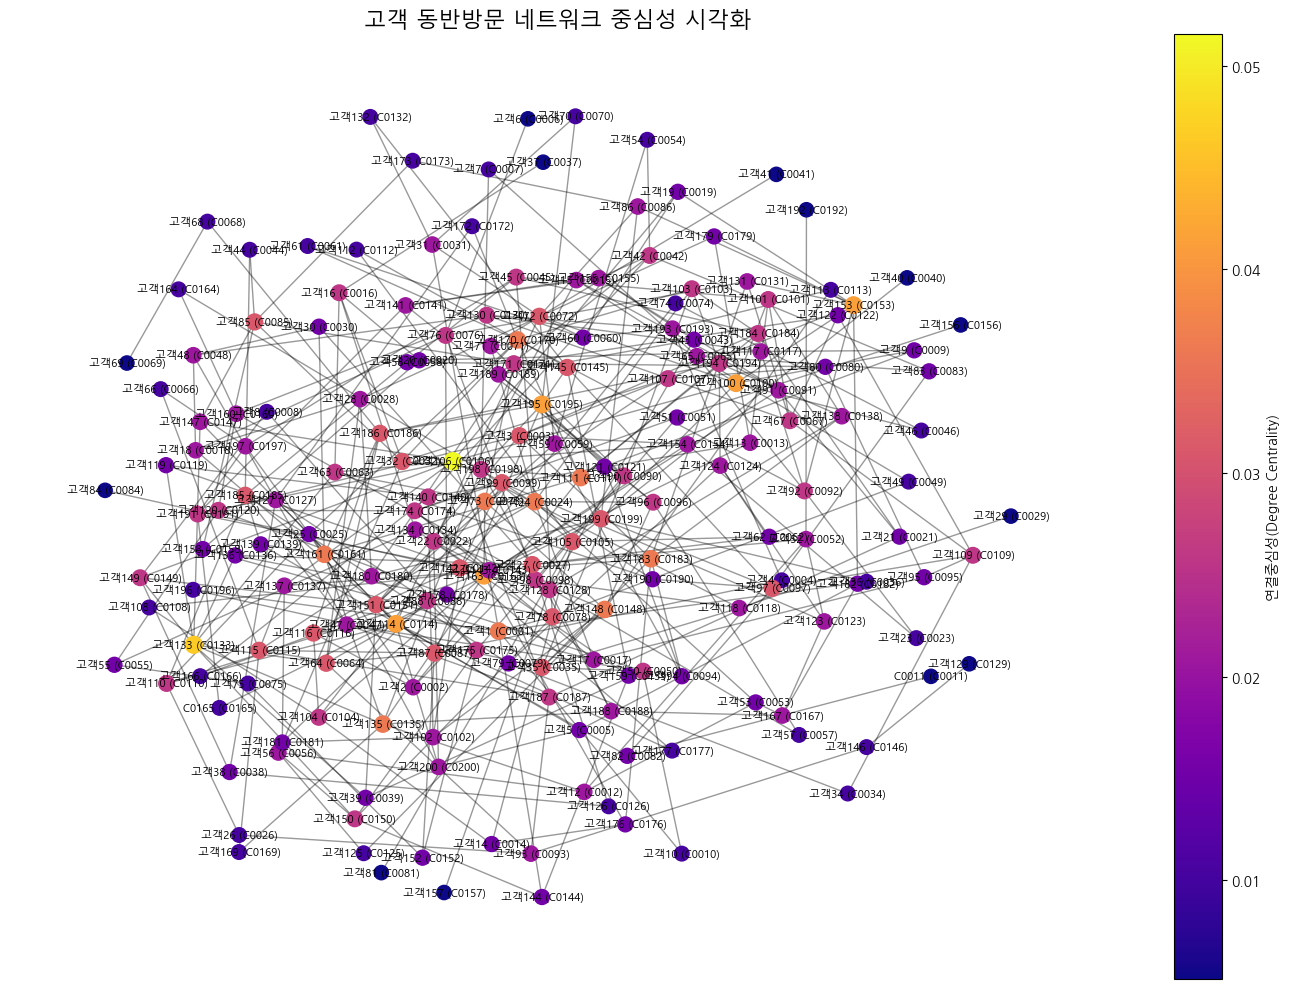

In [5]:
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['axes.unicode_minus'] = False

# 2. 노드 속성 설정
node_colors = [degree_centrality.get(node, 0) for node in G.nodes]
node_sizes = [1000 * degree_centrality.get(node, 0) + 100 for node in G.nodes]

# 3. 노드 위치 계산
pos = nx.spring_layout(G, seed=42, k=0.5)

# 4. 시각화
plt.figure(figsize=(14, 10))

# 노드 시각화 (mappable 반환)
nodes = nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=node_sizes,
    cmap=plt.cm.plasma
)

# 엣지와 레이블
nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=8, font_family=font_prop.get_name())

# ✅ colorbar에 mappable 객체 전달 (여기서 오류가 났던 부분 수정됨)
plt.colorbar(nodes, label="연결중심성(Degree Centrality)")

plt.title("고객 동반방문 네트워크 중심성 시각화", fontproperties=font_prop, fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()